<a href="https://colab.research.google.com/github/joel-musonda/cnn-from-scratch-for-pneumonia-classification/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Installing Kaggle and uploading JSON file**

In [ ]:
# Install Kaggle API & pydicom
!pip install -q kaggle pydicom

from google.colab import files
import os

print("Please upload your kaggle.json file:")
files.upload()

# Configure Kaggle directory and permissions
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print("Kaggle API successfully configured!")


Please upload your kaggle.json file:


Saving kaggle.json to kaggle (1).json
Kaggle API successfully configured!


## **Extracting Sample Data**






In [ ]:
# Create target directory
!mkdir -p rsna_pneumonia
%cd rsna_pneumonia

# Download competition data from kaggle
!kaggle competitions download -c rsna-pneumonia-detection-challenge

# Unzip all archives
print("Unzipping images (this takes ~1-2 minutes)...")
!unzip -q stage_2_train_images.zip -d stage_2_train_images
!unzip -q stage_2_test_images.zip -d stage_2_test_images
!unzip -q stage_2_train_labels.csv.zip
!unzip -q stage_2_detailed_class_info.csv.zip

# Return to root directory
%cd ..
print("Dataset successfully extracted and ready!")


/content/rsna_pneumonia
100% 3.66G/3.66G [00:36<00:00, 108MB/s]

Unzipping images (this takes ~1-2 minutes)...
unzip:  cannot find or open stage_2_train_images.zip, stage_2_train_images.zip.zip or stage_2_train_images.zip.ZIP.
unzip:  cannot find or open stage_2_test_images.zip, stage_2_test_images.zip.zip or stage_2_test_images.zip.ZIP.
unzip:  cannot find or open stage_2_train_labels.csv.zip, stage_2_train_labels.csv.zip.zip or stage_2_train_labels.csv.zip.ZIP.
unzip:  cannot find or open stage_2_detailed_class_info.csv.zip, stage_2_detailed_class_info.csv.zip.zip or stage_2_detailed_class_info.csv.zip.ZIP.
/content
Dataset successfully extracted and ready!


In [ ]:
import os

# Unzip the main dataset inside the rsna_pneumonia folder
!unzip -q rsna_pneumonia/rsna-pneumonia-detection-challenge.zip -d rsna_pneumonia/

# Unzip the nested zip files that were inside it
!unzip -q rsna_pneumonia/stage_2_train_images.zip -d rsna_pneumonia/stage_2_train_images
!unzip -q rsna_pneumonia/stage_2_test_images.zip -d rsna_pneumonia/stage_2_test_images
!unzip -q rsna_pneumonia/stage_2_train_labels.csv.zip -d rsna_pneumonia/
!unzip -q rsna_pneumonia/stage_2_detailed_class_info.csv.zip -d rsna_pneumonia/

print("Extraction complete! Check your sidebar now.")


unzip:  cannot find or open rsna_pneumonia/stage_2_train_images.zip, rsna_pneumonia/stage_2_train_images.zip.zip or rsna_pneumonia/stage_2_train_images.zip.ZIP.
unzip:  cannot find or open rsna_pneumonia/stage_2_test_images.zip, rsna_pneumonia/stage_2_test_images.zip.zip or rsna_pneumonia/stage_2_test_images.zip.ZIP.
unzip:  cannot find or open rsna_pneumonia/stage_2_train_labels.csv.zip, rsna_pneumonia/stage_2_train_labels.csv.zip.zip or rsna_pneumonia/stage_2_train_labels.csv.zip.ZIP.
unzip:  cannot find or open rsna_pneumonia/stage_2_detailed_class_info.csv.zip, rsna_pneumonia/stage_2_detailed_class_info.csv.zip.zip or rsna_pneumonia/stage_2_detailed_class_info.csv.zip.ZIP.
Extraction complete! Check your sidebar now.


## **Verify Data & Plot Sample Image**

--- Data Summary ---
Total entries in labels CSV: 30227

Class breakdown:
class
No Lung Opacity / Not Normal    11821
Lung Opacity                     9555
Normal                           8851
Name: count, dtype: int64


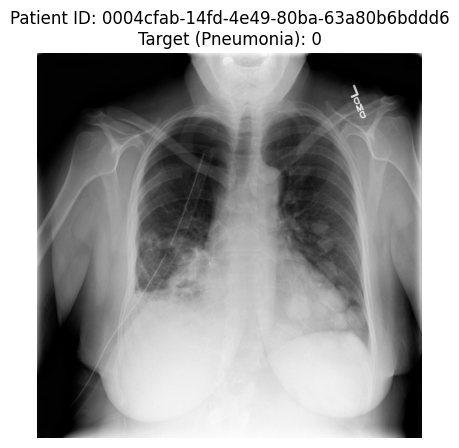

In [ ]:
import pandas as pd
import pydicom
import matplotlib.pyplot as plt

# Load annotations
labels_df = pd.read_csv('rsna_pneumonia/stage_2_train_labels.csv')
class_info_df = pd.read_csv('rsna_pneumonia/stage_2_detailed_class_info.csv')

print("--- Data Summary ---")
print(f"Total entries in labels CSV: {len(labels_df)}")
print("\nClass breakdown:")
print(class_info_df['class'].value_counts())

# Display the first X-ray image
sample_id = labels_df.iloc[0]['patientId']
dcm_path = f"rsna_pneumonia/stage_2_train_images/{sample_id}.dcm"

dcm = pydicom.dcmread(dcm_path)
plt.figure(figsize=(5, 5))
plt.imshow(dcm.pixel_array, cmap='gray')
plt.title(f"Patient ID: {sample_id}\nTarget (Pneumonia): {labels_df.iloc[0]['Target']}")
plt.axis('off')
plt.show()

## **PyTorch Dataset Class & Transforms**

In [ ]:
import os
from PIL import Image
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

class RSNADicomDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        # Clean up duplicates (patients with multiple bounding boxes get a single Target flag)
        self.df = df.groupby('patientId').max().reset_index()
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        patient_id = row['patientId']
        label = row['Target']

        # Build DICOM path
        dcm_path = os.path.join(self.img_dir, f"{patient_id}.dcm")

        # Read DICOM image pixel matrix
        dcm = pydicom.dcmread(dcm_path)
        img_array = dcm.pixel_array.astype(np.float32)

        # Scale to 8-bit [0, 255] range
        img_array = (img_array / np.max(img_array) * 255.0).astype(np.uint8)
        image = Image.fromarray(img_array).convert('L') # Convert to Grayscale PIL image

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.float32)

# Image Transformations
data_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(), # Standardizes values to [0, 1]
    transforms.Normalize(mean=[0.485], std=[0.229])
])

Using device: cpu


# CNN Architecture & Training Loop

In [ ]:
class PneumoniaCNN(nn.Module):
    def __init__(self):
        super(PneumoniaCNN, self).__init__()

        # Conv Block 1
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)

        # Conv Block 2
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)

        # Conv Block 3
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2, 2)

        self.relu = nn.ReLU()

        # Classifier Head
        self.fc1 = nn.Linear(128 * 16 * 16, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 1)

    def forward(self, x):
        x = self.pool1(self.relu(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu(self.bn2(self.conv2(x))))
        x = self.pool3(self.relu(self.bn3(self.conv3(x))))

        x = x.view(x.size(0), -1) # Flatten
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

# Instantiate Dataset and DataLoaders
dataset = RSNADicomDataset(labels_df, 'rsna_pneumonia/stage_2_train_images', transform=data_transforms)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_set, val_set = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader = DataLoader(val_set, batch_size=32, shuffle=False)

# Model, Loss Function, and Optimizer
model = PneumoniaCNN().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training Loop
epochs = 5
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device).unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / train_size
    print(f"Epoch [{epoch + 1}/{epochs}] - Loss: {epoch_loss:.4f}")

Epoch [1/5] - Loss: 0.5250
Epoch [2/5] - Loss: 0.4737
Epoch [3/5] - Loss: 0.4664
Epoch [4/5] - Loss: 0.4571
Epoch [5/5] - Loss: 0.4411


# Confusion Matrix

Evaluating model on validation data...

================ MODEL PERFORMANCE ================
Validation Accuracy : 79.60%
Precision           : 0.8362
Recall (Sensitivity): 0.0831
F1-Score            : 0.1512


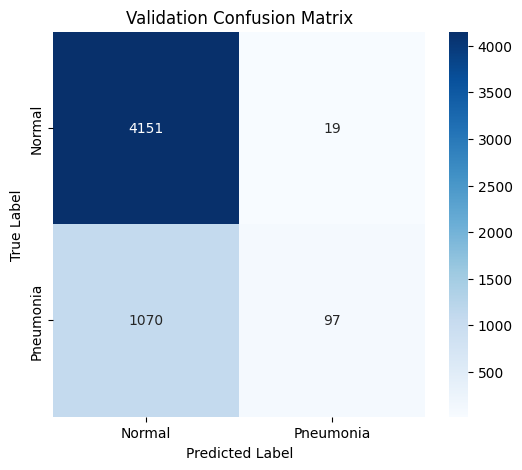

In [ ]:
import numpy as np
import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Evaluate on Validation Set
model.eval()
all_preds = []
all_targets = []

print("Evaluating model on validation data...")
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)

        # Apply Sigmoid to convert raw logits to probabilities [0, 1]
        probs = torch.sigmoid(outputs)

        # Convert probabilities to binary predictions (Threshold = 0.5)
        preds = (probs > 0.5).cpu().numpy().astype(int)

        all_preds.extend(preds)
        all_targets.extend(labels.numpy().astype(int))

# 2. Calculate Metrics
acc = accuracy_score(all_targets, all_preds)
prec = precision_score(all_targets, all_preds)
rec = recall_score(all_targets, all_preds)
f1 = f1_score(all_targets, all_preds)

print("\n================ MODEL PERFORMANCE ================")
print(f"Validation Accuracy : {acc * 100:.2f}%")
print(f"Precision           : {prec:.4f}")
print(f"Recall (Sensitivity): {rec:.4f}")
print(f"F1-Score            : {f1:.4f}")
print("====================================================")

# 3. Plot Confusion Matrix
cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'])
plt.title('Validation Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# **Correcting the Imbalance**

In [ ]:
import torch

# 1. Calculate class imbalance weight
# Penalizes missing pneumonia cases ~3.2x harder
pos_weight = torch.tensor([3.2]).to(device)

# 2. Re-initialize Weighted Loss Function & Model
model = PneumoniaCNN().to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 3. Maintain 5 Epochs for Experimental Consistency
print("Retraining network with Class Weighting (5 Epochs)...")
epochs = 5
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device).unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / train_size
    print(f"Epoch [{epoch + 1}/{epochs}] - Loss: {epoch_loss:.4f}")

In [ ]:
# Evaluate tuned model
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.sigmoid(outputs)

        # Lower threshold to 0.35 to boost sensitivity in medical screening
        preds = (probs > 0.35).cpu().numpy().astype(int)

        all_preds.extend(preds)
        all_targets.extend(labels.numpy().astype(int))

acc = accuracy_score(all_targets, all_preds)
rec = recall_score(all_targets, all_preds)
prec = precision_score(all_targets, all_preds)

print("\n================ TUNED PERFORMANCE ================")
print(f"Validation Accuracy : {acc * 100:.2f}%")
print(f"Precision           : {prec:.4f}")
print(f"Sensitivity (Recall): {rec:.4f}  <-- Look for a big jump here!")
print("====================================================")

cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'])
plt.title('Tuned Validation Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()